In [64]:
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, callbacks

from utils import set_seed
set_seed(42)

 Random seed зафиксирован: 42


#  Подготовка данных

In [65]:
df_features = pd.read_csv('data/features.csv')

target_col = 'consumption'
feature_cols = [col for col in df_features.columns if col not in ['timestamp', target_col]]

split_idx = int(len(df_features) * 0.8)
train_df = df_features.iloc[:split_idx].copy()
test_df = df_features.iloc[split_idx:].copy()

train_X_raw = train_df[feature_cols].values
test_X_raw = test_df[feature_cols].values

train_y_raw = train_df[target_col].values
test_y_raw = test_df[target_col].values

train_dates = pd.to_datetime(train_df['timestamp']).values
test_dates = pd.to_datetime(test_df['timestamp']).values

SEQ_LEN = 24  
HORIZON = 24   

def create_sequences(X_data, y_data, dates_array, seq_len, horizon):
    X, y, dates = [], [], []
    for i in range(len(X_data) - seq_len - horizon + 1):
        X.append(X_data[i : i + seq_len])
        y_window = y_data[i + seq_len : i + seq_len + horizon]
        y.append(np.log1p(y_window)) 
        dates.append(dates_array[i + seq_len]) 
    return np.array(X), np.array(y), np.array(dates)

X_train, y_train, dates_train = create_sequences(train_X_raw, train_y_raw, train_dates, SEQ_LEN, HORIZON)
X_test, y_test, dates_test = create_sequences(test_X_raw, test_y_raw, test_dates, SEQ_LEN, HORIZON)

print(f"X_train: {X_train.shape}, y_train (log): {y_train.shape}")
print(f"X_test:  {X_test.shape}")

X_train: (6825, 24, 57), y_train (log): (6825, 24)
X_test:  (1672, 24, 57)


# Cтандартизация признаков X

In [ ]:
n_features = X_train.shape[2]
scaler = StandardScaler()

X_train_2d = X_train.reshape(-1, n_features)
X_test_2d  = X_test.reshape(-1, n_features)

scaler.fit(X_train_2d)

X_train_scaled = scaler.transform(X_train_2d).reshape(X_train.shape)
X_test_scaled  = scaler.transform(X_test_2d).reshape(X_test.shape)

os.makedirs('model_weights', exist_ok=True)
joblib.dump(scaler, 'model_weights/scaler_lstm.joblib')

['model_weights/scaler_lstm.joblib']

# Кастомная функция потерь 

In [67]:
@tf.keras.utils.register_keras_serializable() 
def asymmetric_profit_loss(y_true, y_pred):
    """
    Штрафует сильнее за недопрогноз (когда факт > прогноза).
    Заставляет модель предсказывать пики с запасом.
    """
    error = y_true - y_pred
    penalty_under = 3.0 
    penalty_over = 1.0
    
    loss = tf.where(error > 0, 
                    tf.square(error) * penalty_under, 
                    tf.square(error) * penalty_over)
    return tf.reduce_mean(loss)

# Архитектура LSTM

In [ ]:
model_lstm = models.Sequential([
    layers.Input(shape=(SEQ_LEN, n_features)),
    
    layers.LSTM(128, return_sequences=True, activation='tanh',
                kernel_regularizer=regularizers.l2(1e-5)), 
    layers.LayerNormalization(), 
 
    layers.LSTM(64, return_sequences=False, activation='tanh',
                kernel_regularizer=regularizers.l2(1e-5)),
    layers.LayerNormalization(), 
   
    layers.Dense(64, activation='swish'),
    layers.Dense(32, activation='swish'),
    
    layers.Dense(HORIZON, activation='linear')
])


In [69]:

model_lstm.compile(
    optimizer=tf.keras.optimizers.Nadam(learning_rate=5e-4, clipvalue=0.5), 
    loss=asymmetric_profit_loss, 
    metrics=['mae']
)

model_lstm.summary()

callbacks_list = [
    callbacks.EarlyStopping(monitor='val_loss', patience=40, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.75, patience=10, min_lr=1e-6, verbose=1),
    callbacks.TerminateOnNaN()
]

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_14 (LSTM)                  │ (None, 24, 128)        │        95,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_14          │ (None, 24, 128)        │           256 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_15 (LSTM)                  │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_15          │ (None, 64)             │           128 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 24)             │           792 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 152,056 (593.97 KB)

 Trainable params: 152,056 (593.97 KB)

 Non-trainable params: 0 (0.00 B)

In [70]:
history_lstm = model_lstm.fit(
    X_train_scaled, y_train,
    epochs=300,
    batch_size=64,
    validation_split=0.1,
    callbacks=callbacks_list,
    verbose=1
)

Epoch 1/300
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - loss: 370.4391 - mae: 10.0022 - val_loss: 86.7945 - val_mae: 4.7485 - learning_rate: 5.0000e-04
Epoch 2/300
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 15.4501 - mae: 1.5291 - val_loss: 0.1118 - val_mae: 0.2603 - learning_rate: 5.0000e-04
Epoch 3/300
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.1174 - mae: 0.2591 - val_loss: 0.1015 - val_mae: 0.2449 - learning_rate: 5.0000e-04
Epoch 4/300
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.1077 - mae: 0.2463 - val_loss: 0.0934 - val_mae: 0.2305 - learning_rate: 5.0000e-04
Epoch 5/300
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0995 - mae: 0.2336 - val_loss: 0.0864 - val_mae: 0.2174 - learning_rate: 5.0000e-04
Epoch 6/300
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0919 - mae: 0.2212 - val_loss: 0.0796 - val_mae: 0.2050 - learning_rate: 5.0000e-04
Epoch 7/300
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0841 - mae: 0.2084 - val_loss: 0.0728 - val_mae: 0.1923 -

# График обучения

In [71]:

def plot_training_history(history, start_epoch=5):
    """
    Визуализация истории обучения, пропуская первые сумасшедшие эпохи 
    для адекватного масштаба графика.
    """
    s = start_epoch - 1
    epochs = range(s + 1, len(history.history['loss']) + 1)
    
    fig, ax = plt.subplots(1, 2, figsize=(18, 6))

    ax[0].plot(epochs, history.history['loss'][s:], label='Train Loss', color='steelblue', linewidth=2)
    ax[0].plot(epochs, history.history['val_loss'][s:], label='Val Loss', color='darkorange', linewidth=2, linestyle='--')
    ax[0].set_title(f'История Loss LSTM (с {start_epoch} эпохи)', fontsize=13, fontweight='bold')
    ax[0].set_xlabel('Эпоха', fontsize=11)
    ax[0].set_ylabel('Value (Asymmetric Loss)', fontsize=11)
    ax[0].legend()
    ax[0].grid(True, alpha=0.3)

    ax[1].plot(epochs, history.history['mae'][s:], label='Train MAE', color='forestgreen', linewidth=2)
    ax[1].plot(epochs, history.history['val_mae'][s:], label='Val MAE', color='crimson', linewidth=2, linestyle='--')
    ax[1].set_title(f'История MAE LSTM (с {start_epoch} эпохи)', fontsize=13, fontweight='bold')
    ax[1].set_xlabel('Эпоха', fontsize=11)
    ax[1].set_ylabel('MAE (Логарифмический масштаб)', fontsize=11)
    ax[1].legend()
    ax[1].grid(True, alpha=0.3)

    plt.tight_layout()
    
    plt.savefig('data/17_lstm_training_history.png', dpi=150, bbox_inches='tight')



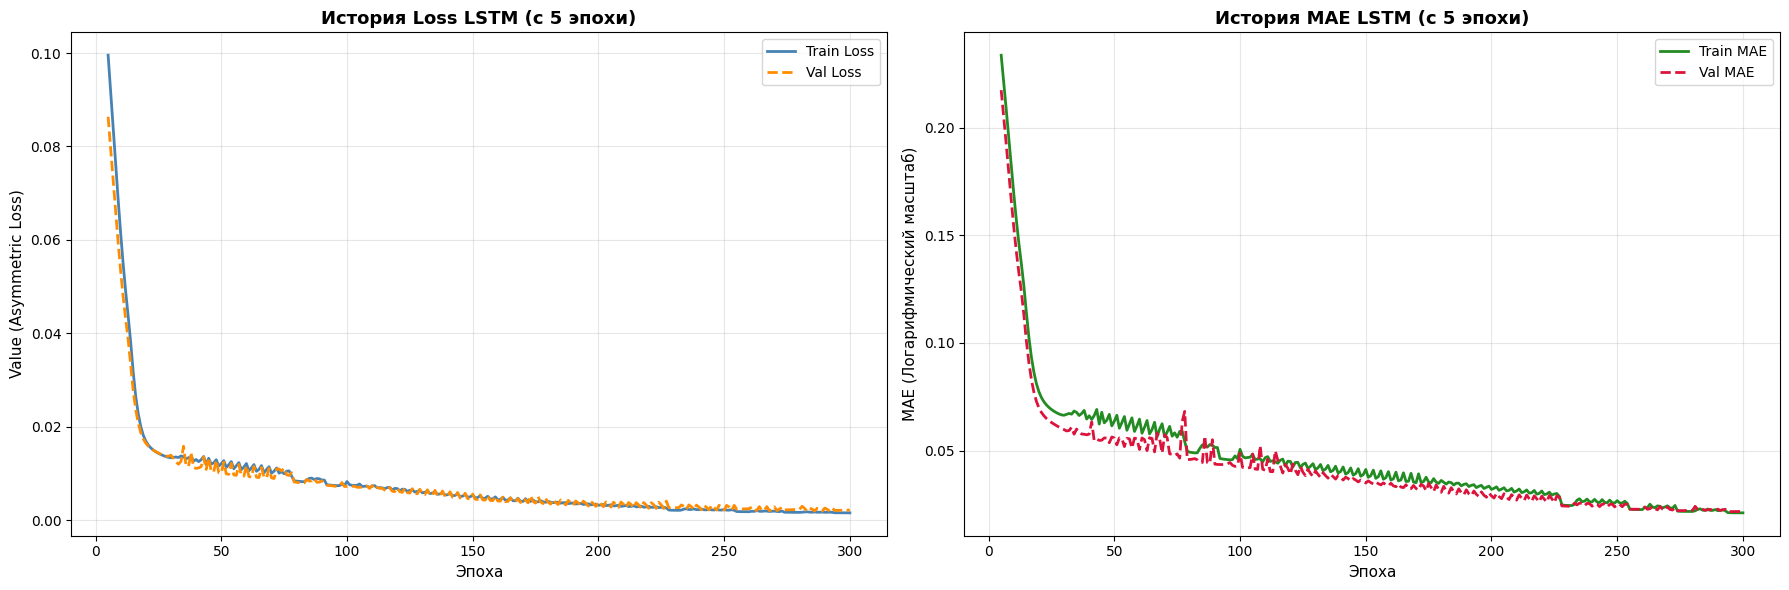

In [ ]:
if len(history_lstm.history['loss']) > 5:
    plot_training_history(history_lstm, start_epoch=5)
else:
    print("Обучение длилось меньше 5 эпох, вывод обрезанного графика невозможен.")

# График предсказания

In [ ]:
y_pred_log = model_lstm.predict(X_test_scaled)

y_pred_real = np.expm1(y_pred_log)
y_test_real = np.expm1(y_test)



53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step


MAE:   126394.80 Вт
RMSE:  181791.91 Вт
MAPE:       3.63 %
R2:       0.9657


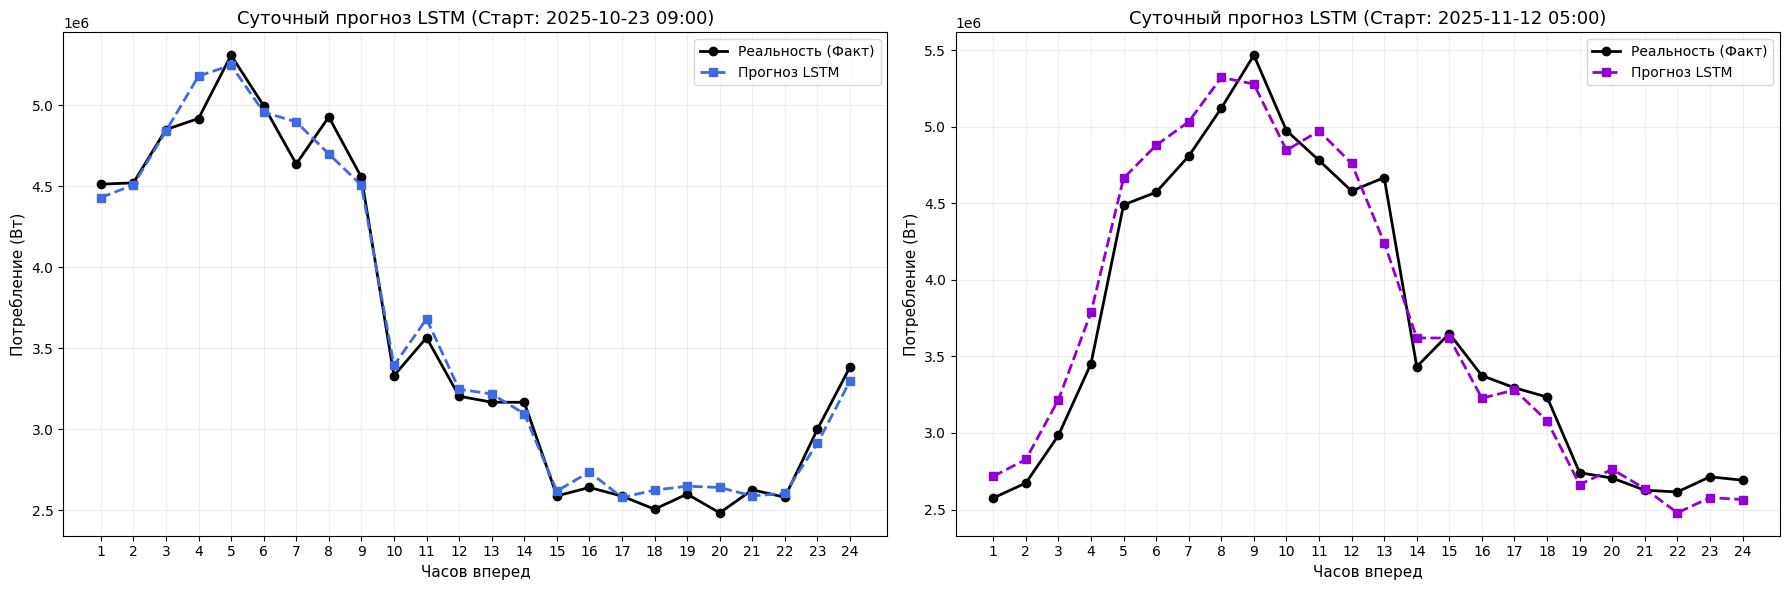

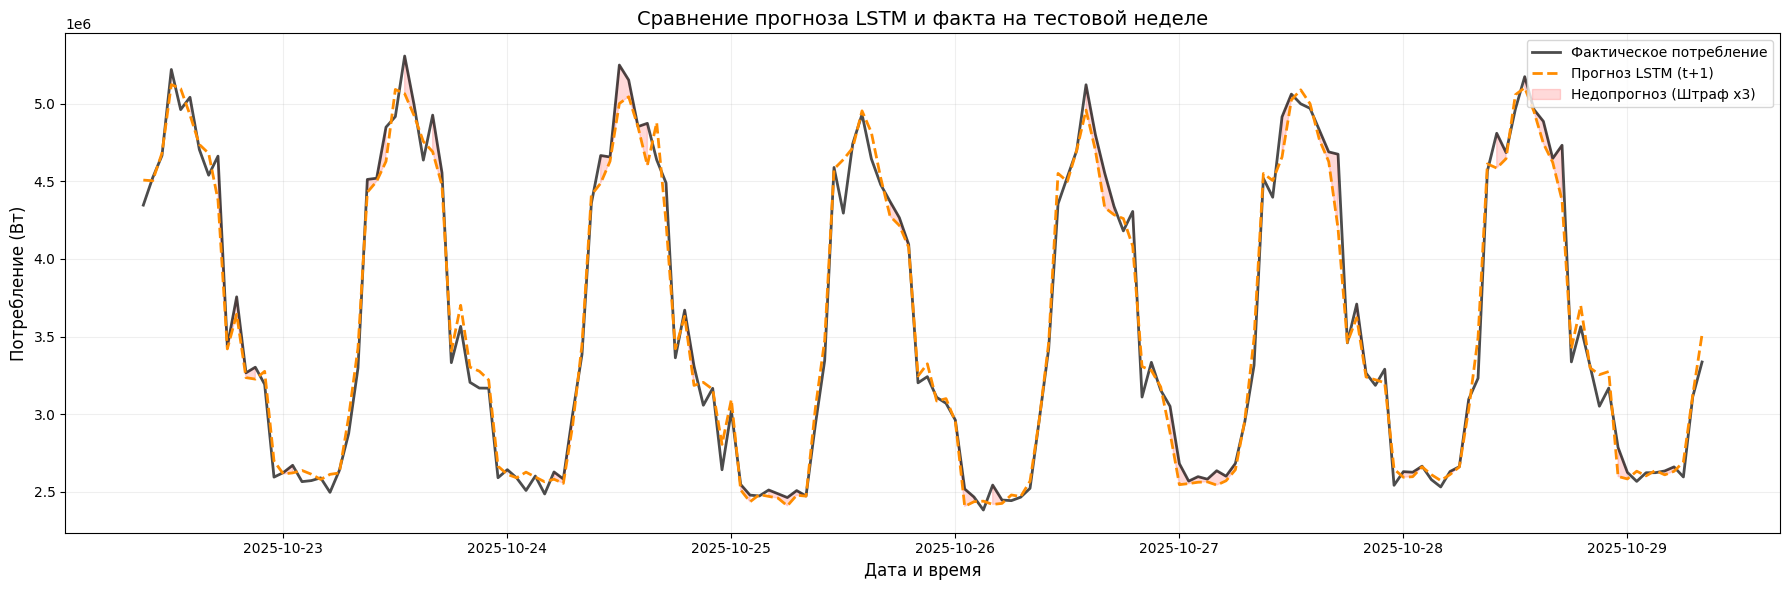

In [76]:
fig, ax = plt.subplots(1, 2, figsize=(18, 6))

sample_indices = [24, 500] 
colors = ['royalblue', 'darkviolet']

for i, idx in enumerate(sample_indices):
    hours_ahead = np.arange(1, 25)
    ax[i].plot(hours_ahead, y_test_real[idx], label='Реальность (Факт)', color='black', marker='o', linewidth=2)
    ax[i].plot(hours_ahead, y_pred_real[idx], label='Прогноз LSTM', color=colors[i], marker='s', linestyle='--', linewidth=2)
    
    start_time = pd.to_datetime(dates_test[idx]).strftime('%Y-%m-%d %H:00')
    ax[i].set_title(f'Суточный прогноз LSTM (Старт: {start_time})', fontsize=13)
    ax[i].set_xlabel('Часов вперед', fontsize=11)
    ax[i].set_ylabel('Потребление (Вт)', fontsize=11)
    ax[i].set_xticks(hours_ahead)
    ax[i].grid(True, alpha=0.2)
    ax[i].legend()

plt.tight_layout()


n_hours = 168 
step_idx = 0 

plt.figure(figsize=(18, 6))
plt.plot(dates_test[:n_hours], y_test_real[:n_hours, step_idx], 
         label='Фактическое потребление', color='black', linewidth=2, alpha=0.7)
plt.plot(dates_test[:n_hours], y_pred_real[:n_hours, step_idx], 
         label='Прогноз LSTM (t+1)', color='darkorange', linewidth=2, linestyle='--')

plt.fill_between(dates_test[:n_hours], y_test_real[:n_hours, step_idx], y_pred_real[:n_hours, step_idx], 
                 where=(y_test_real[:n_hours, step_idx] > y_pred_real[:n_hours, step_idx]),
                 color='red', alpha=0.15, label='Недопрогноз (Штраф x3)')

plt.title('Сравнение прогноза LSTM и факта на тестовой неделе', fontsize=14)
plt.xlabel('Дата и время', fontsize=12)
plt.ylabel('Потребление (Вт)', fontsize=12)
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, alpha=0.2)
plt.tight_layout()

mae_overall = mean_absolute_error(y_test_real, y_pred_real)
rmse_overall = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
mape_overall = np.mean(np.abs((y_test_real - y_pred_real) / y_test_real)) * 100
r2_overall = r2_score(y_test_real, y_pred_real)

print(f"MAE:  {mae_overall:>10.2f} Вт")
print(f"RMSE: {rmse_overall:>10.2f} Вт")
print(f"MAPE: {mape_overall:>10.2f} %")
print(f"R2:   {r2_overall:>10.4f}")

# Сохранение весов

In [77]:
model_lstm.save('model_weights/lstm_model.keras')